# Loading required libraries

In [140]:
library(ggplot2)
library(patchwork)
library(broom)
library(scales)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

# Figures and Files Setup

In [46]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_6"

# Color palettes

In [47]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)

# Load the required data

In [56]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [96]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Abdomen")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Abdomen"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

In [58]:
#read cell type percentages per patient
celltype_percentage_patient <- read.csv(file.path(data_dir, "celltype_percentage_patient.csv"))
cellparent_percentage_patient <- read.csv(file.path(data_dir, "cellparent_percentage_patient.csv"))

In [59]:
#niches df 
niches_df <- read.csv(file.path(data_dir, "niches_df.csv"))

# B

### for plot B, refer to the COZI folder

# C

In [212]:
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1,
                           pt_size_bg = 1.5, pt_size_fg = 1.5) {

  df_bg <- df %>% dplyr::filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% dplyr::filter(cell_category %in% highlight_levels)

  # palette restricted to highlighted cells (keeps your exact colors)
  pal_hl <- full_palette[highlight_levels]
  pal_hl <- pal_hl[!is.na(pal_hl)]  # safety if some names not present

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = pal_hl,
      breaks = highlight_levels,   # <- legend entries limited to highlighted
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}  


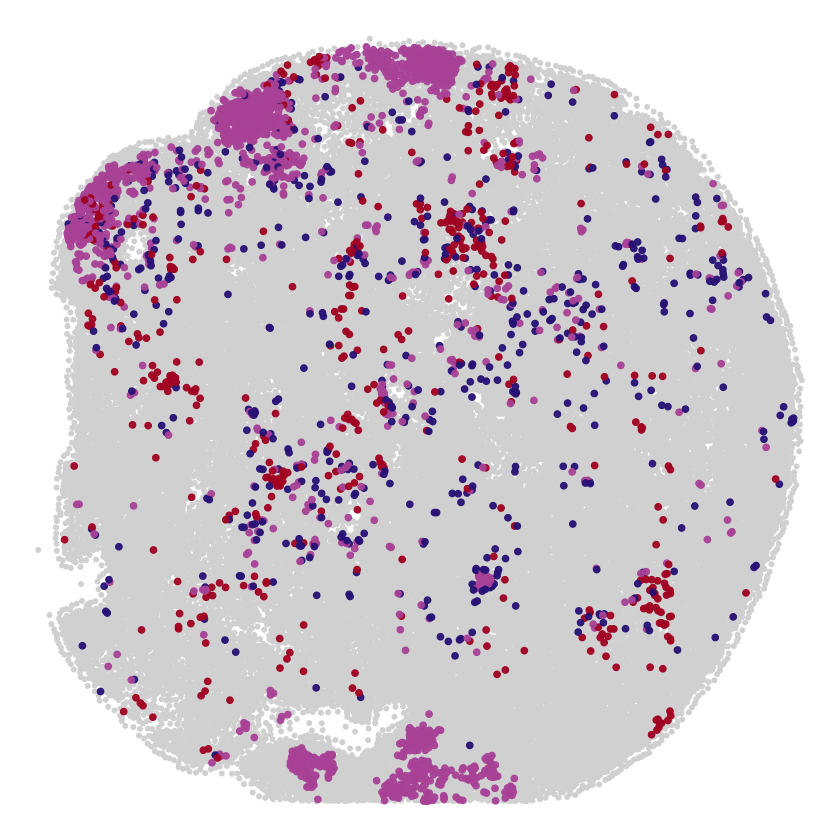

In [216]:
exp <- "NUT_5_ROI11"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 1, pt_size_fg = 1.5,
  highlight_levels = c("MDSCs", "CD8+ T cells", "Granulocytes"))
p

ggsave(filename = file.path(results_dir, "NMC_5_ROI11_mdscscd8.pdf"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

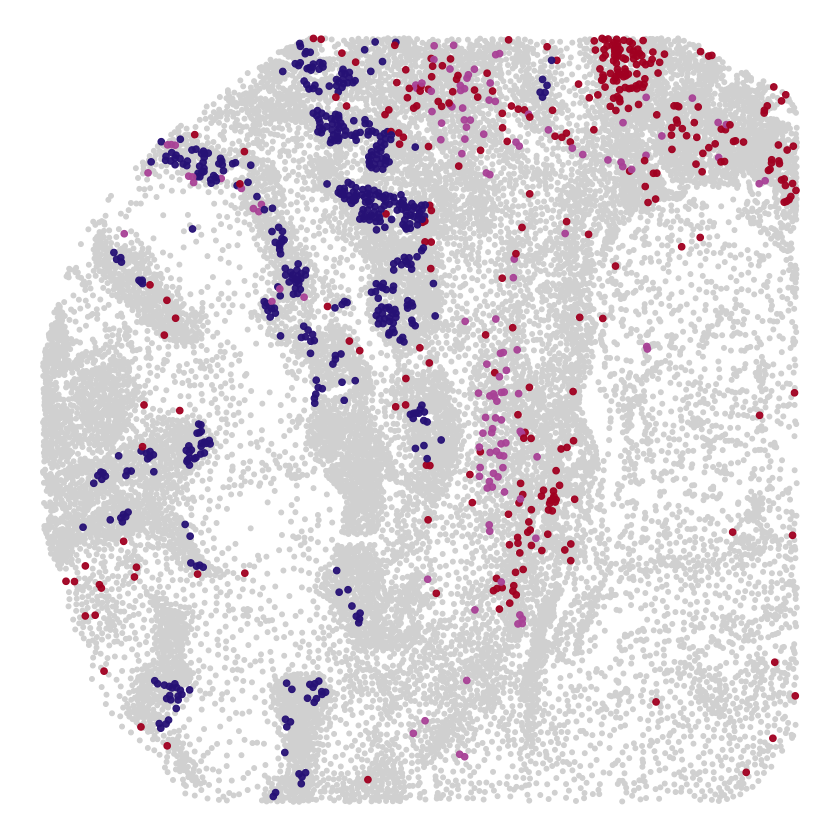

In [217]:
exp <- "NUT_7_ROI13"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 1, pt_size_fg = 1.5,
  highlight_levels = c("MDSCs", "CD8+ T cells", "Granulocytes"))
p

ggsave(filename = file.path(results_dir, "NMC_7_ROI13_mdscscd8.pdf"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

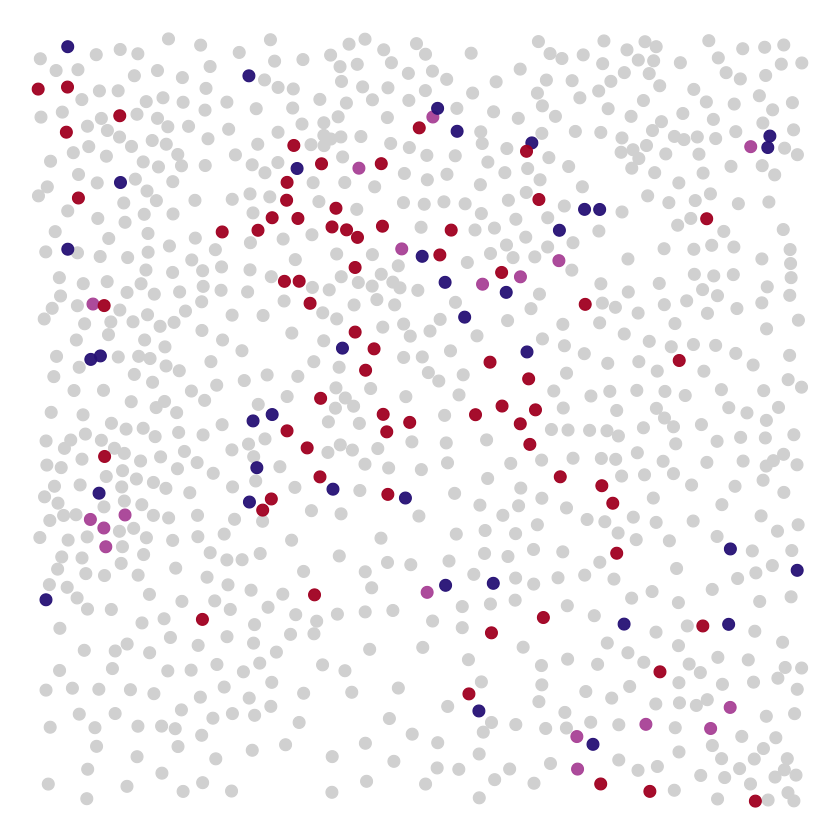

In [218]:
exp <- "NUT_5_ROI11"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 7500 & `Cell Center X` <= 9500, 
    `Cell Center Y` >= 3250 & `Cell Center Y` <= 5250)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "Granulocytes"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_1", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

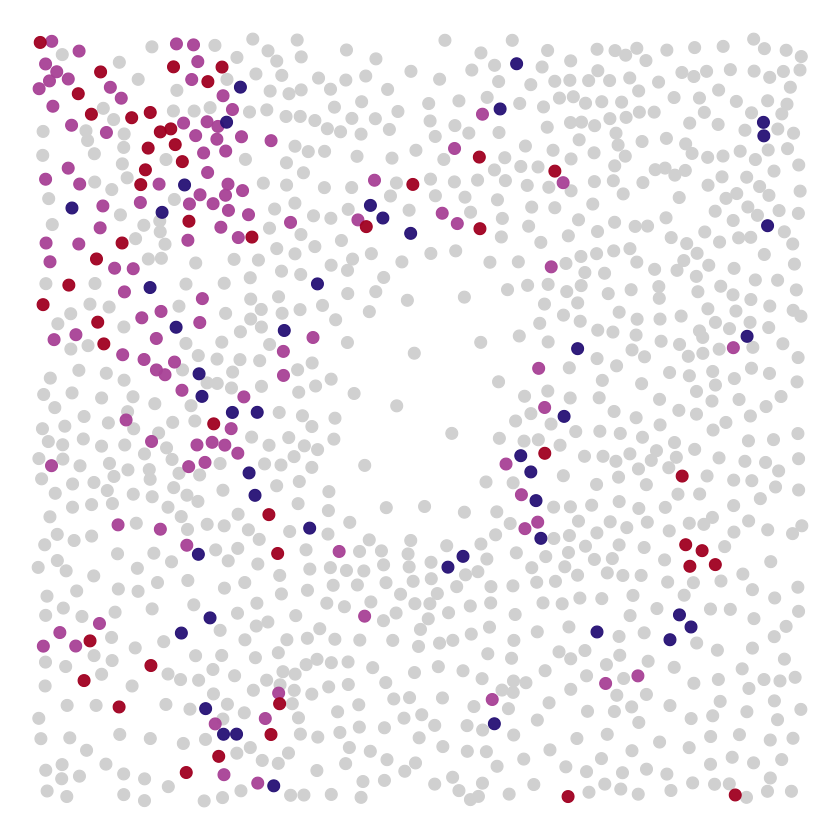

In [219]:
exp <- "NUT_5_ROI11"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 950 & `Cell Center X` <= 2950, 
    `Cell Center Y` >= 3300 & `Cell Center Y` <= 5300)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "Granulocytes"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_2", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

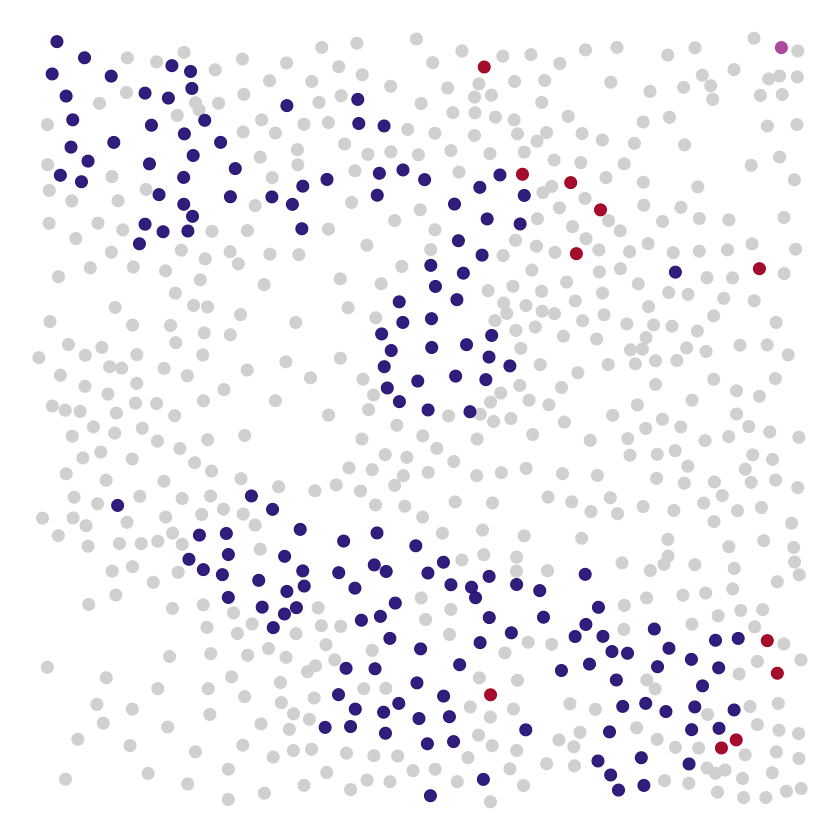

In [220]:
exp <- "NUT_7_ROI13"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 4500 & `Cell Center X` <= 6500, 
    `Cell Center Y` >= 1200 & `Cell Center Y` <= 3200)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "Granulocytes"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_1", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

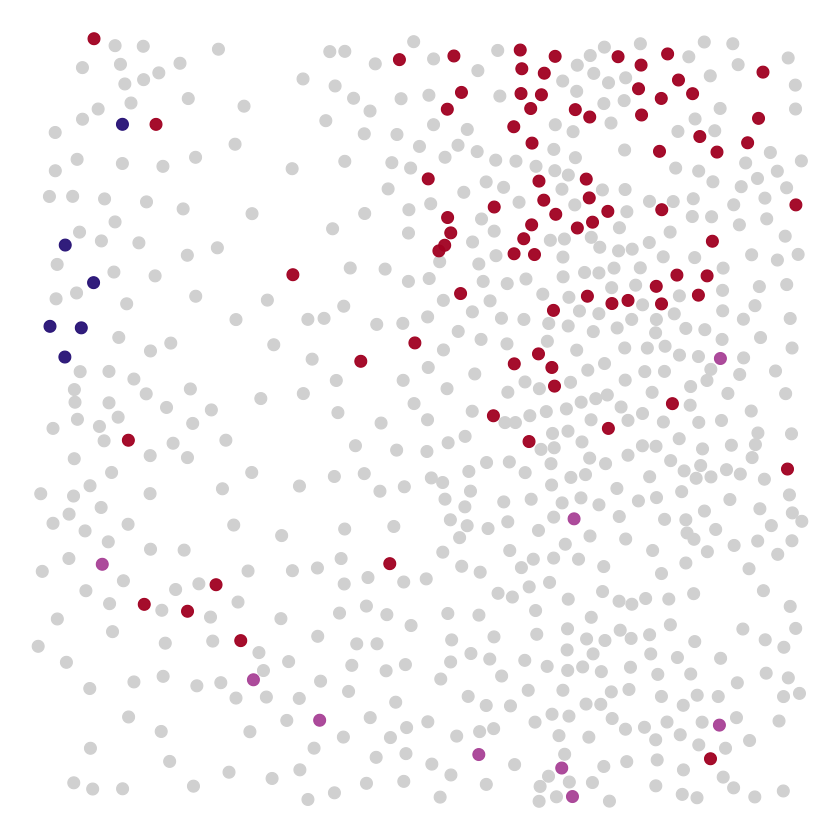

In [221]:
exp <- "NUT_7_ROI13"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 8200 & `Cell Center X` <= 10200, 
    `Cell Center Y` >= 150 & `Cell Center Y` <= 2150)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells", "Granulocytes"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_2", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

## NEW PATIENTS

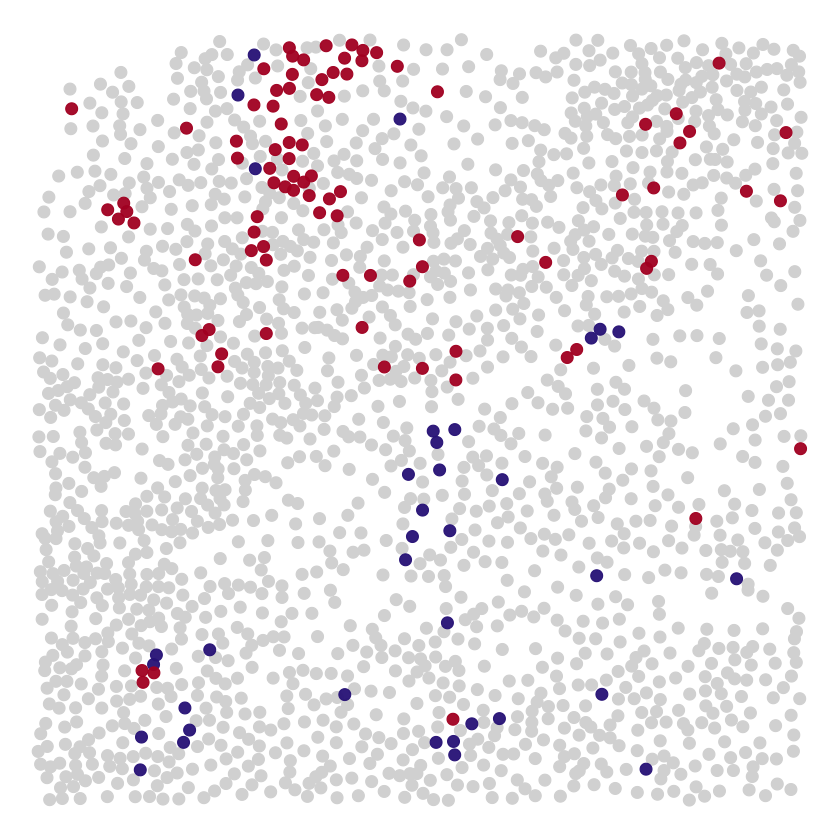

In [14]:
exp <- "NUT_2_ROI1"

df <- celltype_metadata %>%
  filter(patient_exp == exp,
    `Cell Center X` >= 4000 & `Cell Center X` <= 6000, 
    `Cell Center Y` >= 900 & `Cell Center Y` <= 2900)

p <- plot_highlight(
  df,
  pt_size_bg = 3, pt_size_fg = 3,
  highlight_levels = c("MDSCs", "CD8+ T cells"))
p

ggsave(
      filename = paste0(results_dir, "/snapshots_images/", "_", exp, "_1", "_snapshot.png"),
      plot = p,
      width = 5 , height = 5, dpi = 150
    )

# D

In [279]:
#calculate proportions of mdscs for NUT_5 and NUT_7
mdscs_percentage <- celltype_metadata %>%
  filter(patient_ID %in% c("NUT_5", "NUT_7")) %>%
  group_by(patient_ID, patient_exp, cell_category) %>%
    summarise(count = n()) %>%
    ungroup() %>%
    group_by(patient_ID, patient_exp) %>%
    mutate(proportion = count / sum(count)) %>%
    #calculate mean per patient
    group_by(patient_ID, cell_category) %>%
    summarise(mean_proportion = mean(proportion)) %>%
    ungroup() %>%
    filter(cell_category %in% c("MDSCs", "CD8+ T cells")) %>%
    mutate(percentage = mean_proportion * 100)
mdscs_percentage

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID, patient_exp, and
  cell_category.
ℹ Output is grouped by patient_ID and patient_exp.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, patient_exp, cell_category))` for
  per-operation grouping (`?dplyr::dplyr_by`) instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and cell_category.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


patient_ID,cell_category,mean_proportion,percentage
<fct>,<chr>,<dbl>,<dbl>
NUT_5,CD8+ T cells,0.01589405,1.589405
NUT_5,MDSCs,0.01801069,1.801069
NUT_7,CD8+ T cells,0.01081275,1.081275
NUT_7,MDSCs,0.02257018,2.257018


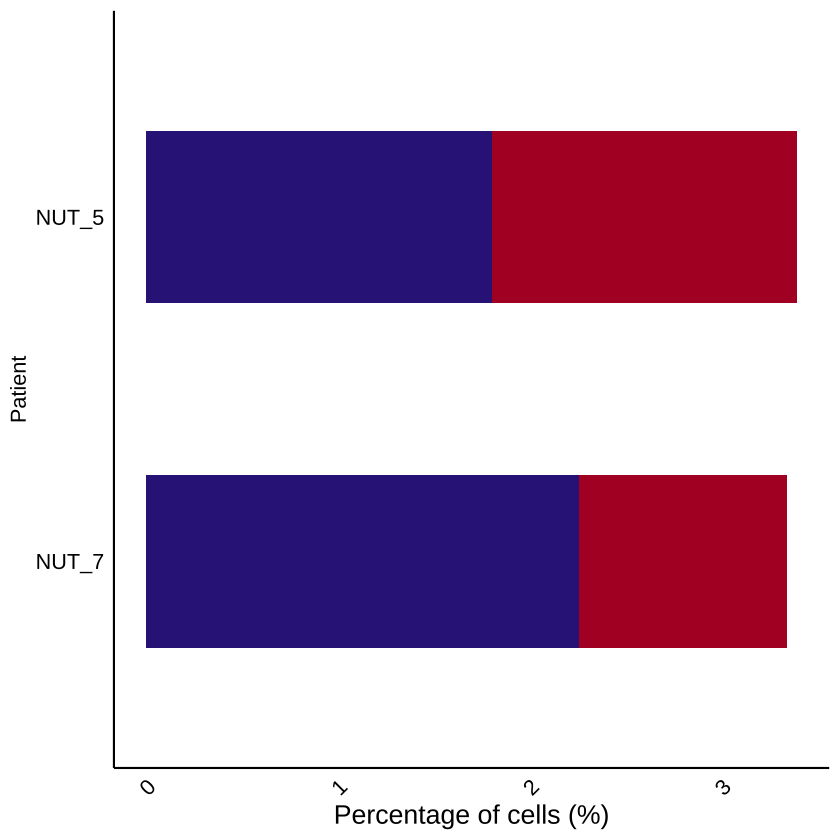

In [280]:
#barplot for comparison 
comparison_barplot <- ggplot(
  mdscs_percentage,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.5) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank())

comparison_barplot

ggsave(
  filename = file.path(results_dir, "patientmdscscd8_composition_barplot.pdf"),
  plot = comparison_barplot,
  width = 4,
  height = 3,
  dpi = 300,
  bg = "white"
)

# E

In [134]:
interaction_df <- read.csv(file.path(data_dir, "myeloid_t_interactions.csv"))
mdscs_interaction <- interaction_df %>%
filter(celltype_A == "MDSCs")

In [52]:
mdscs_percentage <- celltype_percentage_patient %>%
    filter(cell_category == "MDSCs") %>%
    select(patient_ID, clr)
mdscs_percentage

patient_ID,clr
<chr>,<dbl>
NUT_1,0.10664853
NUT_2,-0.14969647
NUT_4,1.47603227
NUT_5,0.43728935
NUT_7,0.64990861
NUT_8,1.06403241
NUT_9,1.32010174
NUT_12,-1.84632854
NUT_13,0.02128253


In [ ]:
for(ct in c("Granulocytes", "M2 macrophages", "MDSCs")) {

  ct_clr <- celltype_percentage_patient %>%
    filter(cell_category == ct) %>%
    select(patient_ID, clr)

  cor_df <- ct_clr %>%
    left_join(survival_df, by = "patient_ID")

  cor_test <- cor.test(cor_df$clr, cor_df$survival_time_months, method = "spearman")
  r_val <- round(cor_test$estimate, 2)
  p_val <- round(cor_test$p.value, 3)

  p_cor <- ggplot(cor_df, aes(x = clr, y = survival_time_months)) +
    geom_point(size = 3, color = "#1D9E75") +
    geom_smooth(method = "lm", se = TRUE, color = "black", linewidth = 1.2, linetype = "dashed") +
    annotate("text",
             x = Inf, y = Inf,
             hjust = 1.1, vjust = 1.5,
             label = paste0("rho = ", r_val, "\np = ", p_val),
             size = 6) +
    labs(
      x = paste0(ct, " Center Log Ratio (CLR)"),  
      y = "Survival time (months)"
    ) +
    theme_minimal(base_size = 16) +
    theme(
      axis.text  = element_text(size = 16, color = "black"),
      axis.title = element_text(size = 16, color = "black"),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
      panel.grid = element_blank()
    )

  ggsave(
    filename = paste0(results_dir, "/clr_survival_", ct, "_correlation.pdf"),
    plot = p_cor,
    width = 6,
    height = 4,
    dpi = 300
  )
}

## F

In [264]:
for(tcell in c("CD4+ T cells", "CD8+ T cells")){
mdscs_interaction_filtered <- mdscs_interaction %>%
        filter(celltype_B == tcell) %>%
        mutate(group = factor(
    ifelse(is.na(zscore), "Low NEP", ifelse(zscore > 2, "High NEP", "Low NEP")),
    levels = c("High NEP", "Low NEP"))) %>%
    left_join(., survival_df %>% select(patient_ID, survival_time_months, event, is_lung), by = "patient_ID")
     # Fit survival
    fit <- survfit(Surv(survival_time_months, event) ~ group, data = mdscs_interaction_filtered)
  
    # Plot
    surv_plot <- ggsurvplot(
      fit,
      data = mdscs_interaction_filtered,
      pval = TRUE,
      conf.int = TRUE,
      risk.table = TRUE,
      risk.table.height = 0.25,
      pval.coord = c(17, 0.7),
      xlim = c(0, 20),
      break.time.by = 5,
      palette = c("#E74C3C", "#2E86AB"),
      xlab = "Time (months)",
      ylab = "Survival probability",
      title = paste("Survival by", "MDSCs", "-", tcell, "NEP"),
      legend.title = paste0("MDSCs", "-", tcell),
      legend.labs = c("High NEP", "Low NEP"),
      risk.table.y.text.col = TRUE,
      risk.table.y.text = FALSE,
      ggtheme = theme_classic(base_size = 13, base_family = "Arial")
    )
    filename <- paste0(results_dir, "/survival_", "MDSCs", "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$plot, 
    width = 7, 
    height = 6, 
    dpi = 300)
    filename <- paste0(results_dir, "/survival_table_", "MDSCs", "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$table, 
    width = 7, 
    height = 2, 
    dpi = 300)
    }

Ignoring unknown labels:
• colour : "MDSCs-CD4+ T cells"
Ignoring unknown labels:
• colour : "MDSCs-CD8+ T cells"


In [265]:
for(tcell in c("CD4+ T cells", "CD8+ T cells")){
mdscs_interaction_filtered <- mdscs_interaction %>%
        filter(celltype_B == tcell) %>%
        mutate(group = factor(
    ifelse(is.na(zscore), "Low NEP", ifelse(zscore > 2, "High NEP", "Low NEP")),
    levels = c("High NEP", "Low NEP"))) %>%
    left_join(., survival_df %>% select(patient_ID, survival_time_months, event, is_lung), by = "patient_ID")
     # Fit survival
    fit <- survfit(Surv(survival_time_months, event) ~ group, data = mdscs_interaction_filtered)
  
    # Plot
    surv_plot <- ggsurvplot(
      fit,
      data = mdscs_interaction_filtered,
      pval = TRUE,
      conf.int = TRUE,
      risk.table = TRUE,
      risk.table.height = 0.25,
      pval.coord = c(17, 0.7),
      xlim = c(0, 20),
      break.time.by = 5,
      palette = c("#E74C3C", "#2E86AB"),
      xlab = "Time (months)",
      ylab = "Survival probability",
      title = paste("Survival by", "MDSCs", "-", tcell, "NEP"),
      legend.title = paste0("MDSCs", "-", tcell),
      legend.labs = c("High NEP", "Low NEP"),
      risk.table.y.text.col = TRUE,
      risk.table.y.text = FALSE,
      ggtheme = theme_classic(base_size = 13, base_family = "Helvetica")
    )
    filename <- paste0(results_dir, "/survival_", "MDSCs", "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$plot, 
    width = 7, 
    height = 6, 
    dpi = 300)
    filename <- paste0(results_dir, "/survival_table_", "MDSCs", "_", tcell, ".pdf")
    ggsave(
    filename = filename, 
    plot = surv_plot$table, 
    width = 7, 
    height = 2, 
    dpi = 300)
    }

Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(

### Cox regression model with tissue

In [99]:
#abundances of granulocytes ...
#has_TLS 
#mdscs_score
#tissue
niches_grouped <- niches_df %>%
  group_by(patient_ID) %>%
  summarise(
    n_total = n(),
    n_TLS = sum(neighborhood == "TLS_like"),
    pct_TLS = 100 * n_TLS / n_total,
    .groups = "drop"
  ) %>%
  mutate(
    "is_TLS" = factor(
      ifelse(pct_TLS >= 1, "Present", "Absent"),
      levels = c("Present", "Absent")
    )
  ) %>%
select(patient_ID, is_TLS)

celltype_percentage_patient_granulocytes <- 
celltype_percentage_patient %>%
filter(cell_category == "Granulocytes") %>%
select(patient_ID, percentage) %>%
rename("Granulocytes_percentage" = percentage)

all_factors <- mdscs_interaction %>%
filter(celltype_B == "CD8+ T cells") %>%
select(patient_ID, zscore_normalized) %>%
rename("MDSCs-CD8_score" = zscore_normalized) %>%
left_join(., niches_grouped) %>%
left_join(., celltype_percentage_patient_granulocytes) %>%
left_join(survival_df, by = "patient_ID") 


Joining with `by = join_by(patient_ID)`
Joining with `by = join_by(patient_ID)`


In [ ]:
library(dplyr)
library(tidyr)

mdsc_cd8_diff <- your_df %>%           # replace your_df with the actual object name
  

mdsc_cd8_diff

Joining with `by = join_by(patient_ID)`


patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B,tumor_site,survival_time_months,event,is_lung
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<chr>
NUT_9,MDSCs-CD8+ T cells,22.9057743,0.110960435,11.227380,MDSCs,CD8+ T cells,Lung,2,1,Lung
NUT_2,MDSCs-CD8+ T cells,5.2955410,0.035744799,4.787234,MDSCs,CD8+ T cells,Lung,3,1,Lung
NUT_4,MDSCs-CD8+ T cells,8.7383982,0.056134291,20.029455,MDSCs,CD8+ T cells,Lung,4,1,Lung
NUT_8,MDSCs-CD8+ T cells,7.6074975,0.048149683,3.453237,MDSCs,CD8+ T cells,Lung,4,1,Lung
NUT_15,MDSCs-CD8+ T cells,1.1842896,0.009448374,4.313544,MDSCs,CD8+ T cells,Lung,5,1,Lung
NUT_13,MDSCs-CD8+ T cells,-0.6318794,-0.005249843,0.000000,MDSCs,CD8+ T cells,Lung,6,1,Lung
NUT_6,MDSCs-CD8+ T cells,0.0000000,NA,NA,MDSCs,CD8+ T cells,Lung,7,1,Lung
NUT_7,MDSCs-CD8+ T cells,0.4043368,0.003438715,1.359509,MDSCs,CD8+ T cells,Lung,10,1,Lung
NUT_5,MDSCs-CD8+ T cells,11.8054416,0.054181068,10.907702,MDSCs,CD8+ T cells,Head and Neck,9,1,Head and Neck/Extrahepatic


Call:
coxph(formula = Surv(survival_time_months, event) ~ zscore + 
    is_lung, data = mdscs_interaction_cd8)

  n= 13, number of events= 12 

                coef exp(coef) se(coef)     z Pr(>|z|)   
zscore        0.3042    1.3556   0.1354 2.248  0.02460 * 
is_lungLung   5.5492  257.0378   2.0442 2.715  0.00664 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

            exp(coef) exp(-coef) lower .95 upper .95
zscore          1.356    0.73768     1.040     1.767
is_lungLung   257.038    0.00389     4.677 14127.151

Concordance= 0.883  (se = 0.039 )
Likelihood ratio test= 21.7  on 2 df,   p=2e-05
Wald test            = 7.37  on 2 df,   p=0.03
Score (logrank) test = 16.44  on 2 df,   p=3e-04


`height` was translated to `width`.
`height` was translated to `width`.


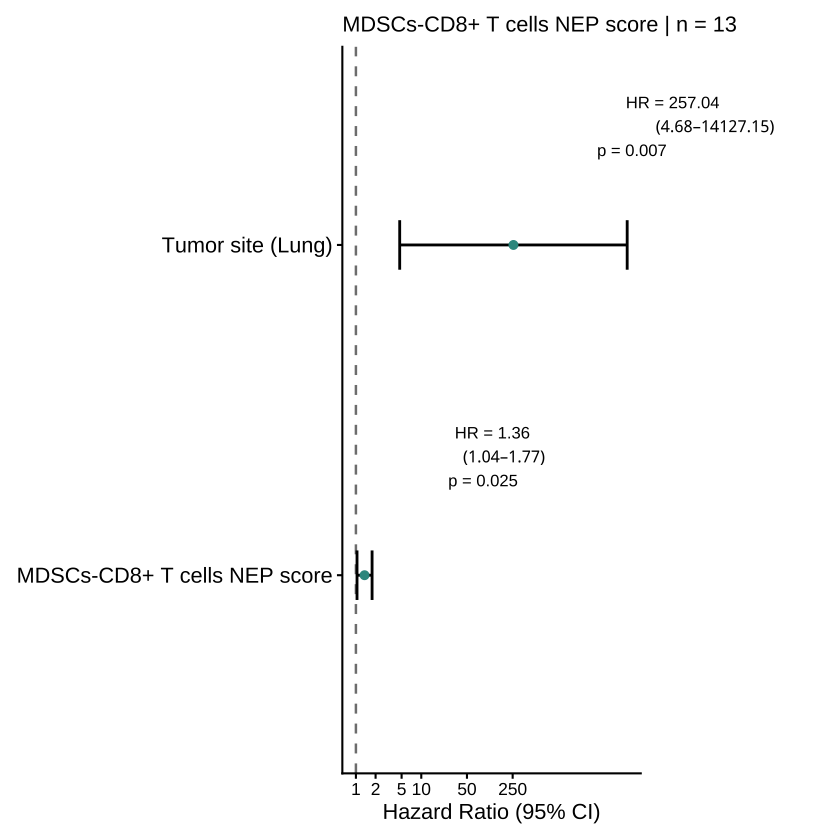

In [ ]:
mdscs_interaction_cd8 <- mdscs_interaction %>%
    filter(celltype_B == "CD8+ T cells") %>%
    left_join(., survival_df) %>%
    #fill NA values with 0
    mutate(zscore = ifelse(is.na(zscore), 0, zscore))
mdscs_interaction_cd8

# Granulocyte effect adjusted for tumor site
cox_mdsc <- coxph(Surv(survival_time_months, event) ~ zscore + is_lung, 
                  data = mdscs_interaction_cd8)
summary(cox_mdsc)

# Tidy the Cox model output
cox_tidy <- tidy(cox_mdsc, exponentiate = TRUE,w conf.int = TRUE) %>%
  mutate(
    term = recode(term,
      "zscore"          = "MDSCs-CD8+ T cells NEP score",
      "is_lungLung"  = "Tumor site (Lung)"
    )
  )

# Forest plot
ggplot(cox_tidy, aes(x = estimate, y = term)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.7) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.15, linewidth = 0.8, color = "black") +
  geom_point(size = 2, color = "#35978F") +
   geom_text(aes(label = sprintf("HR = %.2f\n(%.2f–%.2f)\np = %.3f",
                                 estimate, conf.low, conf.high, p.value)),
            hjust = -1.2, vjust = 0.45, size = 3.5, color = "black", position = position_nudge(y = 0.35))   +
  scale_x_log10(
    breaks = c(0.5, 1, 2, 5, 10, 50, 250),
    labels = c("0.5", "1", "2", "5", "10", "50", "250")
  ) +
  labs(
    x = "Hazard Ratio (95% CI)",
    y = NULL,
    subtitle = "MDSCs-CD8+ T cells NEP score | n = 13"
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.subtitle = element_text(color = "black"),
    axis.text.y   = element_text(size = 13),
    plot.margin   = margin(10, 120, 10, 10)  # right margin for HR labels
  ) +
  coord_cartesian(clip = "off")  # allow labels outside plot area

ggsave(paste0(results_dir, "/cox_forest_plot.pdf"), width = 8, height = 2.5)

In [ ]:
surv

In [18]:
interaction_df %>%
filter(patient_ID == "NUT_7")

patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NUT_7,MDSCs-CD8+ T cells,0.4043368,0.003438715,1.3595093,MDSCs,CD8+ T cells
NUT_7,CD8+ T cells-MDSCs,6.3556017,0.033441506,2.4520231,CD8+ T cells,MDSCs
NUT_7,MDSCs-CD4+ T cells,-8.6805588,-0.085325881,0.8403361,MDSCs,CD4+ T cells
NUT_7,CD4+ T cells-MDSCs,-11.3429061,-0.090870031,1.9553073,CD4+ T cells,MDSCs
NUT_7,M2 macrophages-CD8+ T cells,4.6799590,0.026723926,3.7327325,M2 macrophages,CD8+ T cells
NUT_7,CD8+ T cells-M2 macrophages,5.5936503,0.030653271,19.6457270,CD8+ T cells,M2 macrophages
NUT_7,M2 macrophages-CD4+ T cells,11.0622105,0.062202588,4.5052536,M2 macrophages,CD4+ T cells
NUT_7,CD4+ T cells-M2 macrophages,4.9578192,0.023446475,18.1039617,CD4+ T cells,M2 macrophages
NUT_7,Granulocytes-CD8+ T cells,1.3241063,0.008827756,8.5595137,Granulocytes,CD8+ T cells


In [ ]:
niches_df <- read_csv(paste0(data_dir, "/niches_df.csv")) 
niches_df

Rows: 553331 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): patient_ID, patient_exp, cell_category, neighborhood
dbl (3): Cell Center X, Cell Center Y, survival_time_months

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


patient_ID,patient_exp,cell_category,Cell Center X,Cell Center Y,survival_time_months,neighborhood
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
NUT_1,NUT_1_ROI1,NFC,2480.7239,4857.791,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,3722.4333,2900.642,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,12466.3662,2890.018,170,Tumor_myeloid
NUT_1,NUT_1_ROI3,Tumor cells,2737.7788,2875.279,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,2318.3650,2911.225,170,Tumor_myeloid
NUT_1,NUT_1_ROI3,Tumor cells,603.0942,2886.603,170,Tumor_bulk
NUT_1,NUT_1_ROI3,NFC,11714.1533,2903.130,170,Tumor_NFC
NUT_1,NUT_1_ROI3,NFC,9563.5957,2888.619,170,Tumor_NFC
NUT_1,NUT_1_ROI3,Tumor cells,4836.6763,2890.952,170,Tumor_myeloid


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'Helvetica' not found, will use 'sans' instead”

# A tibble: 4 × 3
  is_lung  surv_group     n
  <fct>    <fct>      <int>
1 Non-Lung Shorter        3
2 Non-Lung Longer         2
3 Lung     Shorter        4
4 Lung     Longer         3


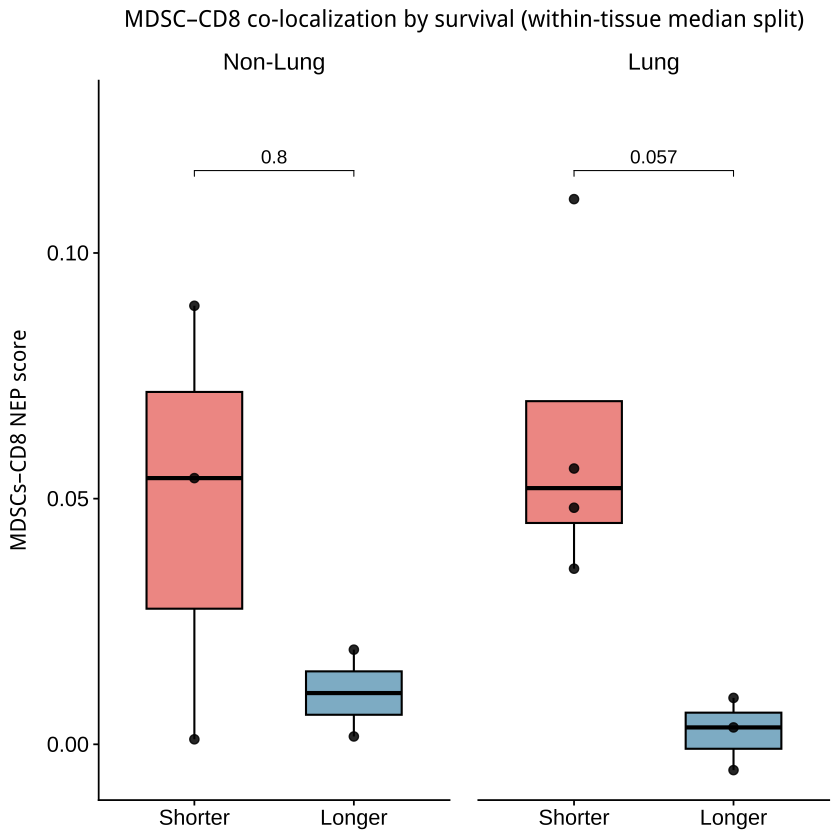

In [108]:
library(dplyr)
library(ggplot2)
library(ggbeeswarm)
library(ggpubr)

plot_df <- all_factors %>%
  filter(!is.na(`MDSCs-CD8_score`)) %>%          # drops NUT_6 (NA score)
  group_by(is_lung) %>%
  mutate(
    med_surv = median(survival_time_months, na.rm = TRUE),
    surv_group = factor(
      ifelse(survival_time_months > med_surv, "Longer", "Shorter"),
      levels = c("Shorter", "Longer")
    )
  ) %>%
  ungroup()

# --- diagnostics: group sizes per facet (check before trusting p) ---
plot_df %>% count(is_lung, surv_group) %>% print()

grp_palette <- c("Shorter" = "#E74C3C", "Longer" = "#2E86AB")

p <- ggplot(plot_df, aes(x = surv_group, y = `MDSCs-CD8_score`, fill = surv_group)) +
  geom_boxplot(outlier.shape = NA, width = 0.6, alpha = 0.6, colour = "black") +
  geom_beeswarm(cex = 3, size = 2.2, alpha = 0.85, colour = "black") +
  stat_compare_means(
    method = "wilcox.test",
    comparisons = list(c("Shorter", "Longer")),
    label = "p.format",
    tip.length = 0.01, size = 4
  ) +
  facet_wrap(~ is_lung) +
  scale_fill_manual(values = grp_palette) +
  labs(
    x = NULL,
    y = "MDSCs–CD8 NEP score",
    title = "MDSC–CD8 co-localization by survival (within-tissue median split)"
  ) +
  theme_classic(base_size = 13) +
  theme(
    legend.position  = "none",
    strip.background = element_blank(),
    strip.text       = element_text(size = 14, colour = "black"),
    panel.spacing    = unit(1.2, "lines"),
    axis.text.x      = element_text(size = 13, colour = "black"),
    axis.text.y      = element_text(size = 13, colour = "black"),
    axis.title.y     = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    plot.title       = element_text(size = 14, hjust = 0.5)
  ) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15)))

p

# ggsave(file.path(results_dir, "MDSC_CD8_by_survival_per_tissue.pdf"),
#        plot = p, width = 7, height = 5, dpi = 300, bg = "white")

In [109]:
niches_df

patient_ID,patient_exp,cell_category,Cell.Center.X,Cell.Center.Y,survival_time_months,neighborhood
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
NUT_1,NUT_1_ROI1,NFC,2480.7239,4857.791,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,3722.4333,2900.642,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,12466.3662,2890.018,170,Tumor_myeloid_enriched
NUT_1,NUT_1_ROI3,Tumor cells,2737.7788,2875.279,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,2318.3650,2911.225,170,Tumor_myeloid_enriched
NUT_1,NUT_1_ROI3,Tumor cells,603.0942,2886.603,170,Tumor_bulk
NUT_1,NUT_1_ROI3,NFC,11714.1533,2903.130,170,Unknown_tumor
NUT_1,NUT_1_ROI3,NFC,9563.5957,2888.619,170,Unknown_tumor
NUT_1,NUT_1_ROI3,Tumor cells,4836.6763,2890.952,170,Tumor_myeloid_enriched


In [ ]:
library(dplyr)
library(tidyr)
library(purrr)
library(coxphf)

# ---- survival: one row per patient (from niches_df, which carries it) ----
# also derive event + is_lung if not already on a patient-level df.
# ASSUMPTION: you have survival_df with patient_ID, survival_time_months, event.
# If event isn't in niches_df, pull it from your survival_df instead.
surv_patient <- niches_df %>%
  distinct(patient_ID, survival_time_months) %>%
  left_join(survival_df %>% distinct(patient_ID, event), by = "patient_ID")

# =====================================================================
# helper: frequency of a cell type, per patient, either tissue-wide or
# restricted to one neighborhood. Two-level: per patient_exp -> mean to patient
# =====================================================================
celltype_freq <- function(df, target_celltype, niche = NULL) {

  d <- df
  scope_label <- "tissue-wide"

  if (!is.null(niche)) {
    # keep only cells in the target niche; frequency = target celltype
    # as a fraction of ALL cells within that niche, per patient_exp
    d <- d %>% filter(neighborhood == niche)
    scope_label <- niche
  }

  # per patient_exp: fraction of cells that are the target cell type
  per_exp <- d %>%
    group_by(patient_ID, patient_exp) %>%
    summarise(
      n_total  = n(),
      n_target = sum(cell_category == target_celltype),
      freq     = 100 * n_target / n_total,
      .groups  = "drop"
    ) %>%
    # guard: drop patient_exp with too few cells in scope (unstable frequency)
    filter(n_total >= 20)

  # up-level to patient: mean of per-exp frequencies
  per_patient <- per_exp %>%
    group_by(patient_ID) %>%
    summarise(
      freq   = mean(freq, na.rm = TRUE),
      n_exp  = n(),
      .groups = "drop"
    ) %>%
    mutate(cell_category = target_celltype, location = scope_label)

  per_patient
}

# =====================================================================
# build the 4 frequency vectors: CD8/CD4 x {TLS_like, tissue-wide}
# =====================================================================
specs <- tribble(
  ~celltype,        ~niche,       ~label,
  "CD8+ T cells",   "TLS_like",   "CD8 in TLS-like",
  "CD8+ T cells",   NULL,         "CD8 tissue-wide",
  "CD4+ T cells",   "TLS_like",   "CD4 in TLS-like",
  "CD4+ T cells",   NULL,         "CD4 tissue-wide"
)

# =====================================================================
# fit one univariable Firth Cox per spec
# =====================================================================
cox_table <- pmap_dfr(specs, function(celltype, niche, label) {

  freq_df <- celltype_freq(niches_df, celltype, niche)

  model_df <- freq_df %>%
    left_join(surv_patient, by = "patient_ID") %>%
    filter(!is.na(survival_time_months), !is.na(event), !is.na(freq)) %>%
    # z-score the frequency so HR reads "per SD" and is comparable across rows
    mutate(freq_z = as.numeric(scale(freq)))

  # need variation + enough patients to fit
  if (nrow(model_df) < 4 || sd(model_df$freq, na.rm = TRUE) == 0) {
    return(tibble(
      cell_category = celltype, location = ifelse(is.null(niche), "tissue-wide", niche),
      label = label, HR = NA, conf.low = NA, conf.high = NA, p.value = NA,
      n = nrow(model_df), events = sum(model_df$event), note = "too few / no variance"
    ))
  }

  fit <- tryCatch(
    coxphf(Surv(survival_time_months, event) ~ freq_z, data = model_df),
    error = function(e) e
  )

  if (inherits(fit, "error")) {
    return(tibble(
      cell_category = celltype, location = ifelse(is.null(niche), "tissue-wide", niche),
      label = label, HR = NA, conf.low = NA, conf.high = NA, p.value = NA,
      n = nrow(model_df), events = sum(model_df$event), note = conditionMessage(fit)
    ))
  }

  tibble(
    cell_category = celltype,
    location      = ifelse(is.null(niche), "tissue-wide", niche),
    label         = label,
    HR            = exp(fit$coefficients[[1]]),
    conf.low      = exp(fit$ci.lower[[1]]),
    conf.high     = exp(fit$ci.upper[[1]]),
    p.value       = fit$prob[[1]],
    n             = nrow(model_df),
    events        = sum(model_df$event),
    note          = ""
  )
})

# BH-correct across the sweep
cox_table <- cox_table %>%
  mutate(p.adj = p.adjust(p.value, method = "BH")) %>%
  select(cell_category, location, label, HR, conf.low, conf.high,
         p.value, p.adj, n, events, note)

print(cox_table)

# write out for the supplement
write.csv(cox_table, file.path(results_dir, "cox_CD8_CD4_TLS_vs_tissuewide.csv"),
          row.names = FALSE)

# A tibble: 4 × 11
  cell_category location    label     HR conf.low conf.high p.value  p.adj     n
  <chr>         <chr>       <chr>  <dbl>    <dbl>     <dbl>   <dbl>  <dbl> <int>
1 CD8+ T cells  TLS_like    CD8 i… 0.460     1.22      2.59  0.0362 0.0928    12
2 CD8+ T cells  tissue-wide CD8 t… 2.09      2.43    109.    0.0850 0.0928    13
3 CD4+ T cells  TLS_like    CD4 i… 0.562     1.32      3.01  0.0928 0.0928    12
4 CD4+ T cells  tissue-wide CD4 t… 2.29      2.58    993.    0.0625 0.0928    13
# ℹ 2 more variables: events <dbl>, note <chr>


In [114]:
interaction_df %>%
filter(patient_ID == "NUT_1")

patient_ID,cell_pair,zscore,zscore_normalized,cond_percent,celltype_A,celltype_B
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
NUT_1,MDSCs-CD8+ T cells,1.68711219,0.019265543,9.5959596,MDSCs,CD8+ T cells
NUT_1,CD8+ T cells-MDSCs,1.10413530,0.008650556,9.2500000,CD8+ T cells,MDSCs
NUT_1,MDSCs-CD4+ T cells,0.03984324,0.001021897,2.8457653,MDSCs,CD4+ T cells
NUT_1,CD4+ T cells-MDSCs,-0.02976645,0.000561398,5.5053191,CD4+ T cells,MDSCs
NUT_1,M2 macrophages-CD8+ T cells,0.74832276,0.009078271,6.7230733,M2 macrophages,CD8+ T cells
NUT_1,CD8+ T cells-M2 macrophages,0.51111612,0.007189310,19.9166667,CD8+ T cells,M2 macrophages
NUT_1,M2 macrophages-CD4+ T cells,1.45932300,0.015245495,5.5094407,M2 macrophages,CD4+ T cells
NUT_1,CD4+ T cells-M2 macrophages,3.00033396,0.028570077,27.9521277,CD4+ T cells,M2 macrophages
NUT_1,Granulocytes-CD8+ T cells,NA,NA,10.0000000,Granulocytes,CD8+ T cells


In [144]:
mdscs_interaction_cd8

patient_ID,MDSCs-CD8+ T cells,CD8+ T cells-MDSCs,zscore_diff,tumor_site,survival_time_months,event,is_lung
<chr>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
NUT_9,22.9057743,-0.27015092,23.1759252,Lung,2,1,Lung
NUT_2,5.2955410,-0.39937320,5.6949142,Lung,3,1,Lung
NUT_4,8.7383982,4.51342525,4.2249730,Lung,4,1,Lung
NUT_8,7.6074975,3.61209064,3.9954069,Lung,4,1,Lung
NUT_15,1.1842896,0.05563428,1.1286553,Lung,5,1,Lung
NUT_13,-0.6318794,-0.63187935,0.0000000,Lung,6,1,Lung
NUT_6,NA,NA,NA,Lung,7,1,Lung
NUT_7,0.4043368,6.35560173,-5.9512649,Lung,10,1,Lung
NUT_5,11.8054416,5.42934729,6.3760943,Head and Neck,9,1,Non-Lung


In [148]:
mdscs_interaction_cd8 <- mdscs_interaction_cd8 %>%
select(patient_ID, zscore_diff, survival_time_months, event, is_lung)

# ---- prep: drop NUT_6 (NA score), z-score the covariate ----
model_df <- mdscs_interaction_cd8 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(MDSC_CD8_z = as.numeric(scale(`zscore_diff`)))

  cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")

# =====================================================================
# 1. Cox: MDSC-CD8 score, stratified by tissue (no lung coefficient spent)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ MDSC_CD8_z + strata(is_lung),
  data = model_df
)
print(summary(fit_cox))

# PH assumption check (Schürch-style: scaled Schoenfeld resid vs time)
ph <- cox.zph(fit_cox)
print(ph)

cox_p  <- summary(fit_cox)$coefficients["MDSC_CD8_z", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["MDSC_CD8_z", "exp(coef)"]



n = 12  events = 11 
Call:
coxph(formula = Surv(survival_time_months, event) ~ MDSC_CD8_z + 
    strata(is_lung), data = model_df)

  n= 12, number of events= 11 

             coef exp(coef) se(coef)    z Pr(>|z|)  
MDSC_CD8_z  2.517    12.393    1.240 2.03   0.0423 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

           exp(coef) exp(-coef) lower .95 upper .95
MDSC_CD8_z     12.39    0.08069     1.091     140.8

Concordance= 0.867  (se = 0.11 )
Likelihood ratio test= 11.3  on 1 df,   p=8e-04
Wald test            = 4.12  on 1 df,   p=0.04
Score (logrank) test = 11.54  on 1 df,   p=7e-04

           chisq df     p
MDSC_CD8_z  2.73  1 0.099
GLOBAL      2.73  1 0.099


n = 12  events = 11 
# A tibble: 2 × 2
  MDSC_group     n
  <fct>      <int>
1 Low            5
2 High           7
# A tibble: 12 × 5
   patient_ID mdsc_to_cd8 cd8_to_mdsc zscore_diff MDSC_group
   <chr>            <dbl>       <dbl>       <dbl> <fct>     
 1 NUT_9           22.9       -0.270       23.2   High      
 2 NUT_16          14.5        3.16        11.3   High      
 3 NUT_5           11.8        5.43         6.38  High      
 4 NUT_2            5.30      -0.399        5.69  High      
 5 NUT_4            8.74       4.51         4.22  High      
 6 NUT_8            7.61       3.61         4.00  High      
 7 NUT_15           1.18       0.0556       1.13  High      
 8 NUT_1            1.69       1.10         0.583 Low       
 9 NUT_13          -0.632     -0.632        0     Low       
10 NUT_12           0.219      0.385       -0.165 Low       
11 NUT_14           0.434      2.84        -2.41  Low       
12 NUT_7            0.404      6.36        -5.95  Low       
Call:
coxph(

Ignoring unknown labels:
• colour : "MDSC–CD8 NEP"
Ignoring unknown labels:
• colour : "MDSC–CD8 NEP"


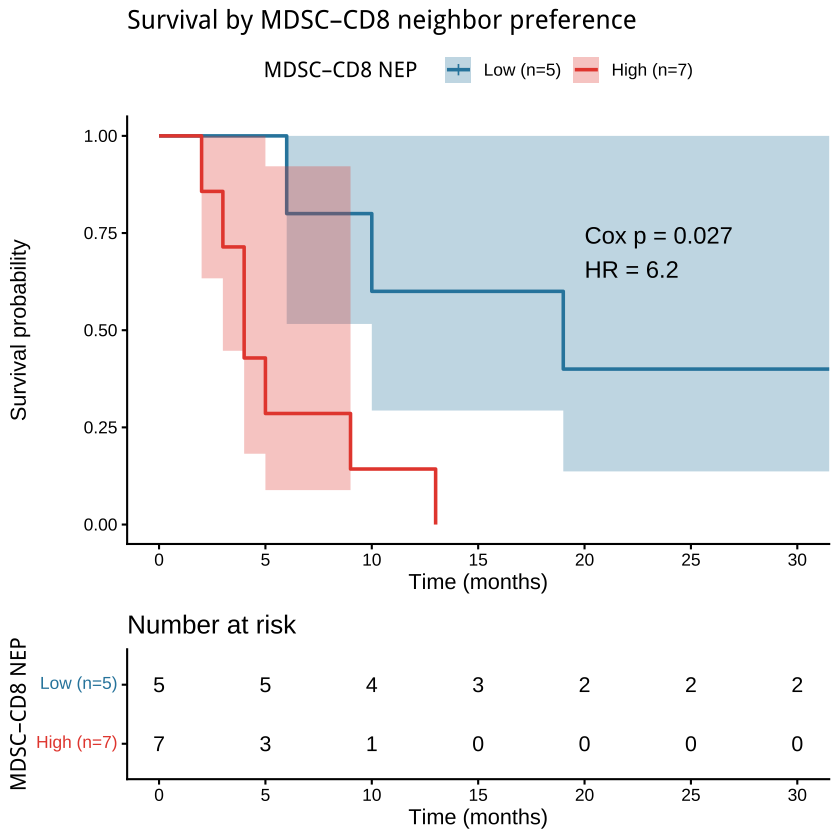

In [172]:
# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN   <- 1     # MDSC->CD8 must exceed CD8->MDSC by at least this
REQUIRE_POS <- TRUE # MDSC->CD8 enrichment must itself be positive

# ---- build per-patient interaction table, keep BOTH directions ----
mdscs_interaction_cd8 <- interaction_df %>%
  filter(cell_pair %in% c("MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs")) %>%
  select(patient_ID, cell_pair, zscore) %>%
  pivot_wider(names_from = cell_pair, values_from = zscore) %>%
  mutate(
    mdsc_to_cd8 = `MDSCs-CD8+ T cells`,       # suppressive direction
    cd8_to_mdsc = `CD8+ T cells-MDSCs`,
    zscore_diff = mdsc_to_cd8 - cd8_to_mdsc   # directional asymmetry
  ) %>%
  left_join(survival_df, by = "patient_ID") %>%
  select(patient_ID, mdsc_to_cd8, cd8_to_mdsc, zscore_diff,
         survival_time_months, event, is_lung)

# ---- prep + define High/Low by the pre-specified rule ----
model_df <- mdscs_interaction_cd8 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(
    is_high = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | mdsc_to_cd8 > 0),
    MDSC_group = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High"))
  )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(MDSC_group) %>% print()
model_df %>% select(patient_ID, mdsc_to_cd8, cd8_to_mdsc, zscore_diff, MDSC_group) %>%
  arrange(desc(zscore_diff)) %>% print()

# =====================================================================
# Cox on the BINARY group (single covariate, no stratification)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ MDSC_group,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["MDSC_groupHigh", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["MDSC_groupHigh", "exp(coef)"]

# =====================================================================
# KM on the pre-specified group
# =====================================================================
fit_km <- survfit(Surv(survival_time_months, event) ~ MDSC_group, data = model_df)

n_high <- sum(model_df$MDSC_group == "High")
n_low  <- sum(model_df$MDSC_group == "Low")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by MDSC\u2013CD8 neighbor preference",
  legend.title = "MDSC\u2013CD8 NEP",
  legend.labs  = c(paste0("Low (n=", n_low, ")"),
                   paste0("High (n=", n_high, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_MDSC_CD8_prespecified_split.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_MDSC_CD8_prespecified_split_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")

n = 12  events = 11 
# A tibble: 2 × 2
  MDSC_group     n
  <fct>      <int>
1 Low            7
2 High           5
# A tibble: 12 × 5
   patient_ID mdsc_to_cd4 cd4_to_mdsc zscore_diff MDSC_group
   <chr>            <dbl>       <dbl>       <dbl> <fct>     
 1 NUT_9          16.5         0.313      16.2    High      
 2 NUT_16         18.6         4.82       13.8    High      
 3 NUT_4           4.00       -0.370       4.37   High      
 4 NUT_7          -8.68      -11.3         2.66   Low       
 5 NUT_5           6.71        5.06        1.65   High      
 6 NUT_15          1.56       -0.0544      1.62   High      
 7 NUT_1           0.0398     -0.0298      0.0696 Low       
 8 NUT_12         -0.105       0.176      -0.281  Low       
 9 NUT_13          0.401       0.932      -0.532  Low       
10 NUT_14          7.44        8.53       -1.10   Low       
11 NUT_2           3.29        8.25       -4.95   Low       
12 NUT_8           1.47        7.13       -5.66   Low       
Call:
coxph(

Ignoring unknown labels:
• colour : "MDSC–CD4 NEP"
Ignoring unknown labels:
• colour : "MDSC–CD4 NEP"


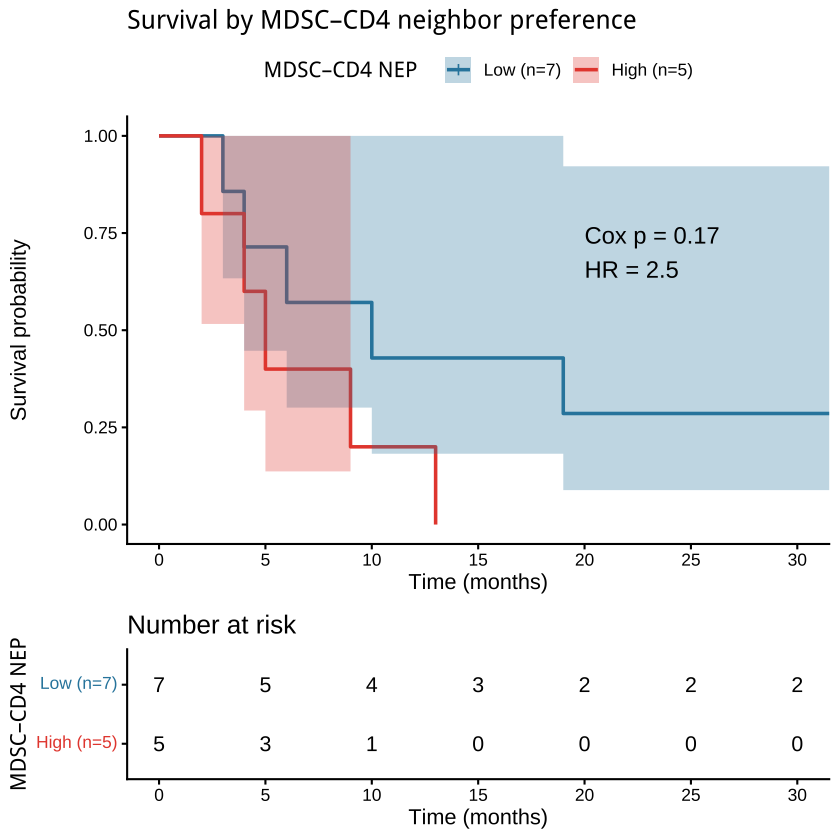

In [173]:
# ---- thresholds (pre-specified, biologically motivated) ----
DIFF_MIN   <- 1     # MDSC->CD8 must exceed CD8->MDSC by at least this
REQUIRE_POS <- TRUE # MDSC->CD8 enrichment must itself be positive

# ---- build per-patient interaction table, keep BOTH directions ----
mdscs_interaction_cd4 <- interaction_df %>%
  filter(cell_pair %in% c("MDSCs-CD4+ T cells", "CD4+ T cells-MDSCs")) %>%
  select(patient_ID, cell_pair, zscore) %>%
  pivot_wider(names_from = cell_pair, values_from = zscore) %>%
  mutate(
    mdsc_to_cd4 = `MDSCs-CD4+ T cells`,       # suppressive direction
    cd4_to_mdsc = `CD4+ T cells-MDSCs`,
    zscore_diff = mdsc_to_cd4 - cd4_to_mdsc   # directional asymmetry
  ) %>%
  left_join(survival_df, by = "patient_ID") %>%
  select(patient_ID, mdsc_to_cd4, cd4_to_mdsc, zscore_diff,
         survival_time_months, event, is_lung)

# ---- prep + define High/Low by the pre-specified rule ----
model_df <- mdscs_interaction_cd4 %>%
  filter(!is.na(zscore_diff), !is.na(survival_time_months), !is.na(event)) %>%
  mutate(
    is_high = (zscore_diff >= DIFF_MIN) & (!REQUIRE_POS | mdsc_to_cd4 > 0),
    MDSC_group = factor(ifelse(is_high, "High", "Low"), levels = c("Low", "High"))
  )

cat("n =", nrow(model_df), " events =", sum(model_df$event), "\n")
model_df %>% count(MDSC_group) %>% print()
model_df %>% select(patient_ID, mdsc_to_cd4, cd4_to_mdsc, zscore_diff, MDSC_group) %>%
  arrange(desc(zscore_diff)) %>% print()

# =====================================================================
# Cox on the BINARY group (single covariate, no stratification)
# =====================================================================
fit_cox <- coxph(
  Surv(survival_time_months, event) ~ MDSC_group,
  data = model_df
)
print(summary(fit_cox))
print(cox.zph(fit_cox))

cox_p  <- summary(fit_cox)$coefficients["MDSC_groupHigh", "Pr(>|z|)"]
cox_hr <- summary(fit_cox)$coefficients["MDSC_groupHigh", "exp(coef)"]

# =====================================================================
# KM on the pre-specified group
# =====================================================================
fit_km <- survfit(Surv(survival_time_months, event) ~ MDSC_group, data = model_df)

n_high <- sum(model_df$MDSC_group == "High")
n_low  <- sum(model_df$MDSC_group == "Low")

km <- ggsurvplot(
  fit_km,
  data        = model_df,
  pval        = paste0("Cox p = ", signif(cox_p, 2),
                       "\nHR = ", signif(cox_hr, 2)),
  pval.coord  = c(20, 0.7),
  conf.int    = TRUE,
  risk.table  = TRUE,
  risk.table.height = 0.28,
  palette     = c("#2E86AB", "#E74C3C"),
  xlab        = "Time (months)",
  ylab        = "Survival probability",
  title       = "Survival by MDSC\u2013CD4 neighbor preference",
  legend.title = "MDSC\u2013CD4 NEP",
  legend.labs  = c(paste0("Low (n=", n_low, ")"),
                   paste0("High (n=", n_high, ")")),
    xlim        = c(0, 30),          # zoom to where events happen
  break.time.by = 5,              # ticks every 10 months
  ggtheme     = theme_classic(base_size = 13)
)
km

ggsave(file.path(results_dir, "KM_MDSC_CD4_prespecified_split.pdf"),
       plot = km$plot, width = 7, height = 5, dpi = 300, bg = "white")
ggsave(file.path(results_dir, "KM_MDSC_CD4_prespecified_split_table.pdf"),
       plot = km$table, width = 7, height = 2, dpi = 300, bg = "white")